In [ ]:
# Importación de las librerías + declaración variables globales
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
from sklearn.preprocessing   import StandardScaler
import seaborn as sns
from sklearn.linear_model     import LinearRegression, Ridge, Lasso, RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection  import train_test_split
from sklearn.metrics          import mean_squared_error, mean_absolute_error, r2_score

RANDOM_STATE=42 

# Importación de los datos

# lista con las variables más predictivas propuestas por Nando
winner_var_list = ["OverallQual","GrLivArea","TotalBsmtSF","GarageCars","YearBuilt","Neighborhood","BsmtQual","KitchenQual"]

# Lista con todas las variables categóricas que si tienen NA, indican algo diferente a valor faltante
filter_meaning = ["Alley", "BsmtQual", "BsmtCond","BsmtExposure",
                  "BsmtFinType1","BsmtFinType2","FireplaceQu",
                  "GarageType","GarageFinish","GarageQual","GarageCond",
                  "PoolQC","Fence","MiscFeature"]

In [14]:
# Carga de datos
dataset_df = pd.read_csv("train.csv")
dataset_df.head(3)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500


# FASE A - Análisis Exploratorio (EDA)

## Identificación de NaN
Cuidado con el valor NA. Para algunas variables indican que no tienen x cosa,
    no que falte el dato.

In [11]:
dataset_df[winner_var_list].info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   OverallQual   1460 non-null   int64 
 1   GrLivArea     1460 non-null   int64 
 2   TotalBsmtSF   1460 non-null   int64 
 3   GarageCars    1460 non-null   int64 
 4   YearBuilt     1460 non-null   int64 
 5   Neighborhood  1460 non-null   object
 6   BsmtQual      1423 non-null   object
 7   KitchenQual   1460 non-null   object
dtypes: int64(5), object(3)
memory usage: 91.4+ KB


In [19]:
dataset_df[winner_var_list].head()

,OverallQual,GrLivArea,TotalBsmtSF,GarageCars,YearBuilt,Neighborhood,BsmtQual,KitchenQual
0,7,1710,856,2,2003,CollgCr,Gd,Gd
1,6,1262,1262,2,1976,Veenker,Gd,TA
2,7,1786,920,2,2001,CollgCr,Gd,Gd
3,7,1717,756,3,1915,Crawfor,TA,Gd
4,8,2198,1145,3,2000,NoRidge,Gd,Gd


In [17]:
# Observación de las variables categóricas con NA, que implican valores faltantes
na_serie = dataset_df[winner_var_list].isna().sum()
na_serie[na_serie>0].drop(index=filter_meaning, errors = "ignore")

Series([], dtype: int64)

In [18]:
# Obtención de los nombres de las variables categóricas con NA, que implican valores faltantes
columns_index_with_na = na_serie[na_serie>0].drop(index=filter_meaning, errors = "ignore").index
columns_index_with_na

Index([], dtype='object')

## Precio

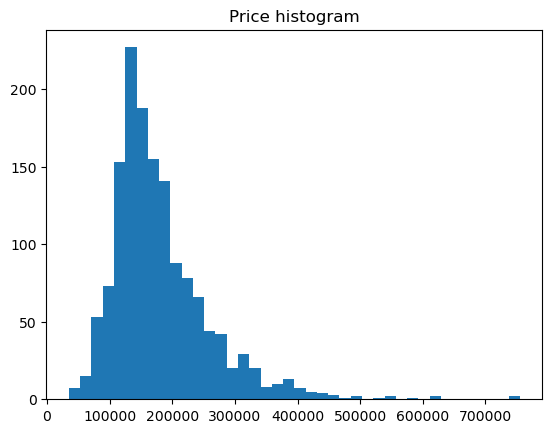

In [7]:
plt.hist(dataset_df["SalePrice"], bins = 40)
plt.title("Price histogram")
plt.show()

# Es necesario normalizar la variable objetivo

## Observación de variables a utilizar en el modelo


### Las variables a utilizar en este modelo son:
    "OverallQual" : Variable numérica discreta del 1 al 10
    "GrLivArea" : Variable numérica continua
    "TotalBsmtSF" : Variable numérica continua
    "GarageCars" : Variable numérica discreta
    "YearBuilt" : Variable numérica discreta
    "Neighborhood" : Variable categórica nominal
    "BsmtQual" : Variable categórica ordinal
    "KitchenQual" : Variable categórica ordinal

In [29]:
model_df = dataset_df.copy()
model_df["BsmtQual"].fillna(0)

"""for i in winner_var_list:
    plt.figure(figsize=(4, 3))
    plt.scatter( x = model_df[i], y = model_df["SalePrice"])
    plt.title("SalePrice vs " + i)
    plt.xlabel(i)
    plt.ylabel("SalePrice")
    plt.show()"""

'for i in winner_var_list:\n    plt.figure(figsize=(4, 3))\n    plt.scatter( x = model_df[i], y = model_df["SalePrice"])\n    plt.title("SalePrice vs " + i)\n    plt.xlabel(i)\n    plt.ylabel("SalePrice")\n    plt.show()'

# FASE B - Limpieza y preprocesado

## Eliminación de outliers

In [ ]:
# Yo eliminaría más puntos de GrLivArea, no solo los 2 naranjas

## Normalización de variables

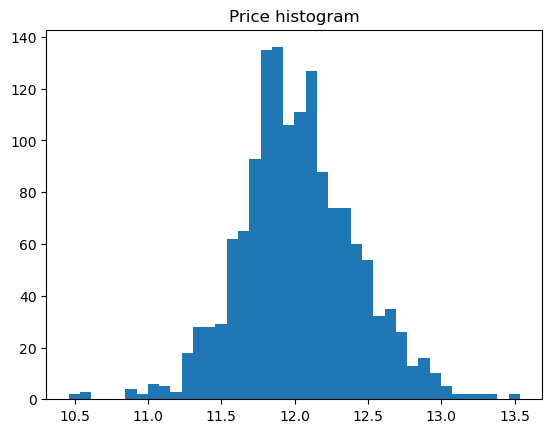

In [27]:
# Normalización de la variable objetivo "SalePrice" PENDIENTE
plt.hist(np.log1p(dataset_df["SalePrice"]), bins = 40)
plt.title("Price histogram")
plt.show()

# FASE C - Ingeniería de características

# FASE D - Modelado

# FASE E - Validación

# FASE F - Envío y posicionamiento